# Plots on real Catherina damage data

Reproduit les figures de `working_paper_plots.ipynb` en utilisant les données réelles générées dans `national_damages.ipynb`.
Chaque figure est tracée pour un seul modèle / scénario à la fois (configurable ci-dessous).

Structure des données d'entrée :
- `data/output/damages/national/{model}/{experiment}/*.parquet`
- Colonnes : `year`, `country`, `country_code`, `seed`, `losses`
- La dimension **seeds** joue le rôle de l'ensemble de Monte-Carlo (équivalent aux `n_samples` du notebook fictif).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import polars as pl

## Configuration

Choisir le modèle et le scénario à analyser.

In [2]:
# --- Modèle et scénario ---
model = "ACCESS-CM2"
experiment = "ssp585"   # ex: historical, ssp245, ssp370, ssp585

# Libellé lisible pour les titres
experiment_labels = {
    "historical": "Historical",
    "ssp245": "SSP2-RCP4.5",
    "ssp370": "SSP3-RCP7.0",
    "ssp585": "SSP5-RCP8.5",
}
scenario_label = experiment_labels.get(experiment, experiment)

output_dir = Path(f"./data/output/damages/national/{model}/{experiment}")
print(f"Modèle : {model}  |  Scénario : {scenario_label}")
print(f"Dossier : {output_dir}")

Modèle : ACCESS-CM2  |  Scénario : SSP5-RCP8.5
Dossier : data/output/damages/national/ACCESS-CM2/ssp585


## Chargement des données

In [3]:
all_losses = pl.read_parquet(output_dir / "*.parquet").to_pandas()
print(f"Lignes : {len(all_losses):,}  |  Colonnes : {list(all_losses.columns)}")
all_losses.head()

Lignes : 57,816,335  |  Colonnes : ['year', 'seed', 'month', 'lat_left', 'lon_left', 'final_wind_speed', 'country', 'value', 'relative_losses', 'losses']


,year,seed,month,lat_left,lon_left,final_wind_speed,country,value,relative_losses,losses
0,2025,0,10,12.500484,-106.500000,NaN,United States of America,835582272.0,NaN,NaN
1,2025,0,10,12.461908,-106.572353,20.010991,United States of America,835582272.0,0.000000e+00,0.000000
2,2025,0,10,12.434372,-106.662559,25.799422,United States of America,835582272.0,8.353381e-09,6.979937
3,2025,0,10,12.417464,-106.769879,28.656213,United States of America,835582272.0,2.195451e-04,183447.968425
4,2025,0,10,12.410696,-106.893604,27.779322,United States of America,835582272.0,7.640888e-05,63845.908918


In [4]:
# Dommages globaux (toutes nations) par (année, seed)
global_by_seed = (
    all_losses
    .groupby(["year", "seed"], as_index=False)["losses"]
    .sum()
)

# Tableau pivotant : lignes = années, colonnes = seeds
pivot = global_by_seed.pivot(index="year", columns="seed", values="losses").sort_index()
years_arr = pivot.index.values          # array 1D d'années
damages_matrix = pivot.values           # shape (n_years, n_seeds)

n_years, n_seeds = damages_matrix.shape
print(f"Années : {years_arr[0]} – {years_arr[-1]}  |  Seeds : {n_seeds}")

Années : 2025 – 2099  |  Seeds : 200


## Figure 11 — Statistiques annuelles des dommages

- **(a)** Percentiles 90 et 95 calculés sur l'ensemble des seeds pour chaque année
- **(b)** Moyenne annuelle avec bande ± écart-type glissant (fenêtre 10 ans)

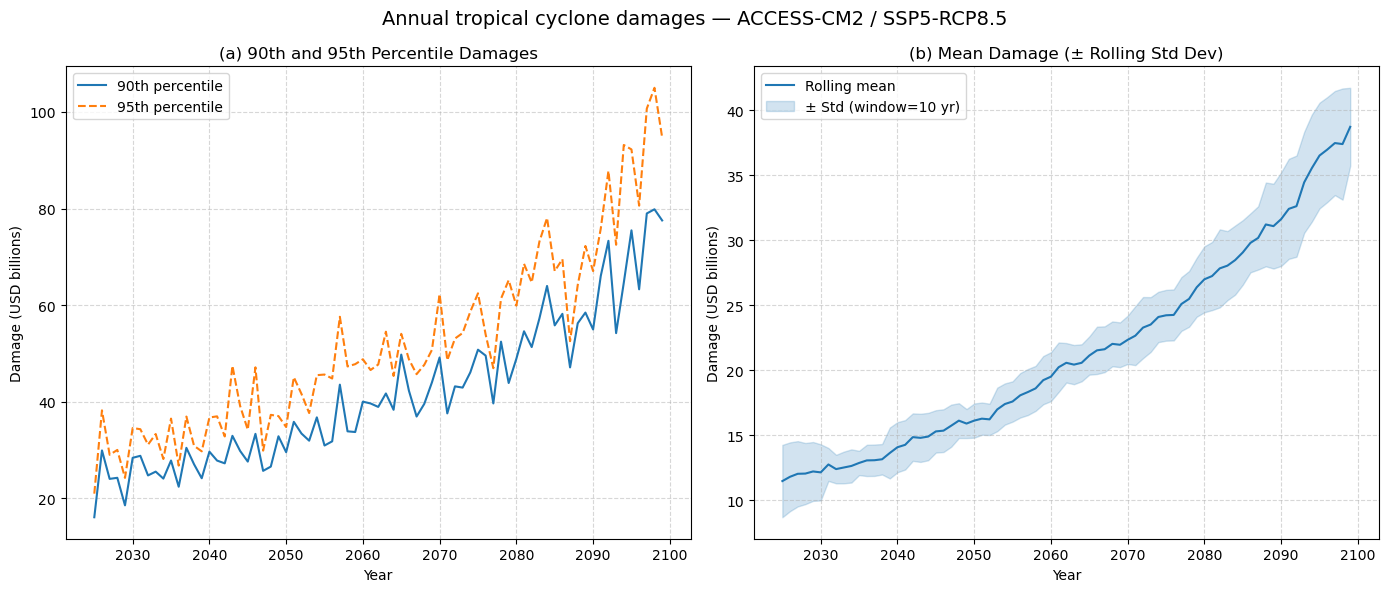

In [5]:
window = 10

annual_mean   = np.nanmean(damages_matrix, axis=1)
annual_p90    = np.nanpercentile(damages_matrix, 90, axis=1)
annual_p95    = np.nanpercentile(damages_matrix, 95, axis=1)

rolling_mean = (
    pd.Series(annual_mean, index=years_arr)
    .rolling(window, center=True, min_periods=1)
    .mean()
    .values
)
rolling_std = (
    pd.Series(annual_mean, index=years_arr)
    .rolling(window, center=True, min_periods=1)
    .std(ddof=0)
    .values
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True)

# (a) percentiles
axes[0].plot(years_arr, annual_p90 / 1e9, label="90th percentile", color="tab:blue")
axes[0].plot(years_arr, annual_p95 / 1e9, label="95th percentile", color="tab:orange", linestyle="--")
axes[0].set_title("(a) 90th and 95th Percentile Damages")
axes[0].set_ylabel("Damage (USD billions)")
axes[0].set_xlabel("Year")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.5)

# (b) mean + rolling std
axes[1].plot(years_arr, rolling_mean / 1e9, label="Rolling mean", color="tab:blue")
axes[1].fill_between(
    years_arr,
    (rolling_mean - rolling_std) / 1e9,
    (rolling_mean + rolling_std) / 1e9,
    color="tab:blue", alpha=0.2, label=f"± Std (window={window} yr)"
)
axes[1].set_title("(b) Mean Damage (± Rolling Std Dev)")
axes[1].set_ylabel("Damage (USD billions)")
axes[1].set_xlabel("Year")
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.5)

fig.suptitle(
    f"Annual tropical cyclone damages — {model} / {scenario_label}",
    fontsize=14
)
plt.tight_layout()
plt.show()

## Figures 12/13 — Évolution temporelle des dommages globaux

Trois vues pour le modèle/scénario sélectionné :
1. Percentiles 90 et 95 par année
2. Moyenne + scatter des seeds individuels
3. Moyenne + plage 5–95 % ombragée

In [ ]:
def plot_percentiles(ax, years, mat, color, label_prefix, percentiles=(90, 95)):
    p_low  = np.nanpercentile(mat, percentiles[0], axis=1)
    p_high = np.nanpercentile(mat, percentiles[1], axis=1)
    ax.plot(years, p_low  / 1e9, label=f"{label_prefix} {percentiles[0]}th pct", color=color, linestyle="-")
    ax.plot(years, p_high / 1e9, label=f"{label_prefix} {percentiles[1]}th pct", color=color, linestyle="--", alpha=0.8)


def plot_mean_scatter(ax, years, mat, color, label, scatter_stride=6, max_points=30):
    means = np.nanmean(mat, axis=1)
    rng = np.random.default_rng(42)
    for i in range(0, len(years), scatter_stride):
        n_pts  = min(mat.shape[1], max_points)
        jitter = rng.normal(0, 0.8, size=n_pts)
        ax.scatter(
            np.full(n_pts, years[i]) + jitter,
            mat[i, :n_pts] / 1e9,
            color=color, alpha=0.25, s=10
        )
    ax.plot(years, means / 1e9, label=f"{label} mean", color=color)


def plot_mean_shaded(ax, years, mat, color, label, p_lo=5, p_hi=95, shade_alpha=0.18):
    means = np.nanmean(mat, axis=1)
    low   = np.nanpercentile(mat, p_lo,  axis=1)
    high  = np.nanpercentile(mat, p_hi, axis=1)
    ax.plot(years, means / 1e9, label=f"{label} mean", color=color)
    ax.fill_between(
        years, low / 1e9, high / 1e9,
        color=color, alpha=shade_alpha,
        label=f"{label} {p_lo}–{p_hi}% range"
    )

In [ ]:
color = "tab:blue"

fig, axes = plt.subplots(1, 3, figsize=(22, 5), sharex=True)

plot_percentiles(axes[0], years_arr, damages_matrix, color, label_prefix=scenario_label)
axes[0].set_title("90th and 95th Percentile Damages", pad=10)
axes[0].set_ylabel("Annual Damages (USD billions)")
axes[0].set_xlabel("Year")
axes[0].legend(fontsize=8)
axes[0].grid(True, linestyle="--", alpha=0.5)

plot_mean_scatter(axes[1], years_arr, damages_matrix, color, label=scenario_label)
axes[1].set_title(f"{model}\nMean Damages with Individual Seed Scatter", pad=10, fontsize=12, fontweight="bold")
axes[1].set_xlabel("Year")
axes[1].legend(fontsize=8)
axes[1].grid(True, linestyle="--", alpha=0.5)

plot_mean_shaded(axes[2], years_arr, damages_matrix, color, label=scenario_label, p_lo=5, p_hi=95)
axes[2].set_title("Mean Damages with Shaded 90% Range", pad=10)
axes[2].set_xlabel("Year")
axes[2].legend(fontsize=8)
axes[2].grid(True, linestyle="--", alpha=0.5)

for ax in axes:
    ax.set_xlim(years_arr[0], years_arr[-1])

plt.tight_layout()
plt.show()

## Figure 14 — Barplots des dommages annuels (années sélectionnées)

Chaque barre montre la **moyenne** des dommages tous seeds confondus pour une année donnée.
Les moustaches représentent l'**erreur standard** ; le texte indique l'écart-type.

In [ ]:
# Années à afficher (adapter selon la plage disponible)
all_available_years = sorted(pivot.index.tolist())
historical_years = [y for y in [1980, 1990, 2000, 2010] if y in all_available_years]
future_years     = [y for y in range(2025, 2101, 10)     if y in all_available_years]

print(f"Années historiques disponibles : {historical_years}")
print(f"Années futures disponibles     : {future_years}")

def build_year_data(years_list):
    """Retourne dict{year: array_of_losses_across_seeds}."""
    data = {}
    for y in years_list:
        row = pivot.loc[y].dropna().values
        if len(row) > 0:
            data[y] = row
    return data

hist_data   = build_year_data(historical_years)
future_data = build_year_data(future_years)


def plot_barplot_single(ax, data, years, title, xtick_rotation=0, ylabel=None, color="tab:blue"):
    means, ses, stds, xs = [], [], [], []
    for i, y in enumerate(years):
        if y not in data:
            continue
        arr  = np.asarray(data[y])
        mean = arr.mean()
        std  = arr.std(ddof=1)
        se   = std / np.sqrt(len(arr))
        means.append(mean / 1e9)
        ses.append(se   / 1e9)
        stds.append(std  / 1e9)
        xs.append(i)

    ax.bar(xs, means, yerr=ses, color=color, capsize=6, edgecolor="black", linewidth=0.8, width=0.6)
    max_se = max(ses) if ses else 0
    for x, m, std in zip(xs, means, stds):
        ax.text(x, m + 0.05 * abs(m) + max_se, f"±{std:.1f}", fontsize=8, ha="center", va="bottom", rotation=90)

    valid_years = [y for y in years if y in data]
    ax.set_xticks(range(len(valid_years)))
    ax.set_xticklabels([str(y) for y in valid_years], rotation=xtick_rotation)
    ax.set_title(title)
    if ylabel:
        ax.set_ylabel(ylabel)
    ax.grid(True, linestyle="--", alpha=0.4, axis="y")


if not future_data:
    fig, axes = plt.subplots(1, 1, figsize=(10, 5))
    axes = [axes]
    plot_barplot_single(axes[0], hist_data, historical_years, f"Historical — {model}",
                        ylabel="Global Damages (USD billions)")
else:
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    plot_barplot_single(axes[0], hist_data, historical_years, f"(a) Historical — {model}",
                        ylabel="Global Damages (USD billions)")
    plot_barplot_single(axes[1], future_data, future_years, f"(b) {scenario_label} — {model}",
                        xtick_rotation=45)

fig.suptitle(
    f"Mean annual damages with standard error — {model} / {scenario_label}",
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.show()

## Figure 15 — Boxplots des dommages annuels (années sélectionnées)

La distribution des boîtes à moustaches est calculée sur l'ensemble des **seeds** pour chaque année.

In [ ]:
def plot_boxplot_single(ax, data, years, title, xtick_rotation=0, ylabel=None, color="tab:blue"):
    valid_years = [y for y in years if y in data]
    box_data    = [data[y] / 1e9 for y in valid_years]

    bp = ax.boxplot(box_data, positions=range(len(valid_years)), widths=0.5, patch_artist=True)
    for patch in bp["boxes"]:
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    for median in bp["medians"]:
        median.set_color("black")

    ax.set_xticks(range(len(valid_years)))
    ax.set_xticklabels([str(y) for y in valid_years], rotation=xtick_rotation)
    ax.set_title(title)
    if ylabel:
        ax.set_ylabel(ylabel)
    ax.grid(True, linestyle="--", alpha=0.4, axis="y")


if not future_data:
    fig, axes = plt.subplots(1, 1, figsize=(10, 5))
    axes = [axes]
    plot_boxplot_single(axes[0], hist_data, historical_years, f"Historical — {model}",
                        ylabel="Global Damages (USD billions)")
else:
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    plot_boxplot_single(axes[0], hist_data, historical_years, f"(a) Historical — {model}",
                        ylabel="Global Damages (USD billions)")
    plot_boxplot_single(axes[1], future_data, future_years, f"(b) {scenario_label} — {model}",
                        xtick_rotation=45)

fig.suptitle(
    f"Boxplot of annual damages across seeds — {model} / {scenario_label}",
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.show()

## Bonus — Analyse par pays

Mêmes figures 11/14/15 restreintes à un pays particulier (ex. États-Unis).

In [ ]:
country_code = "US"   # code ISO2 utilisé dans all_losses

country_losses = (
    all_losses[all_losses["country_code"] == country_code]
    .groupby(["year", "seed"], as_index=False)["losses"]
    .sum()
)

pivot_country = (
    country_losses
    .pivot(index="year", columns="seed", values="losses")
    .sort_index()
)
years_c   = pivot_country.index.values
damages_c = pivot_country.values
print(f"Pays : {country_code}  |  Années : {years_c[0]}–{years_c[-1]}  |  Seeds : {damages_c.shape[1]}")

In [ ]:
window = 10

c_mean = np.nanmean(damages_c, axis=1)
c_p90  = np.nanpercentile(damages_c, 90, axis=1)
c_p95  = np.nanpercentile(damages_c, 95, axis=1)
c_rmean = pd.Series(c_mean, index=years_c).rolling(window, center=True, min_periods=1).mean().values
c_rstd  = pd.Series(c_mean, index=years_c).rolling(window, center=True, min_periods=1).std(ddof=0).values

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

axes[0].plot(years_c, c_p90 / 1e9, label="90th percentile", color="tab:orange")
axes[0].plot(years_c, c_p95 / 1e9, label="95th percentile", color="tab:red", linestyle="--")
axes[0].set_title(f"(a) Percentiles — {country_code}")
axes[0].set_ylabel("Damage (USD billions)")
axes[0].set_xlabel("Year")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.5)

axes[1].plot(years_c, c_rmean / 1e9, label="Rolling mean", color="tab:orange")
axes[1].fill_between(
    years_c,
    (c_rmean - c_rstd) / 1e9,
    (c_rmean + c_rstd) / 1e9,
    color="tab:orange", alpha=0.2, label=f"± Std (window={window} yr)"
)
axes[1].set_title(f"(b) Mean ± rolling std — {country_code}")
axes[1].set_xlabel("Year")
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.5)

fig.suptitle(
    f"Annual damages — {country_code} — {model} / {scenario_label}",
    fontsize=13
)
plt.tight_layout()
plt.show()

In [ ]:
hist_years_c   = [y for y in [1980, 1990, 2000, 2010] if y in pivot_country.index]
future_years_c = [y for y in range(2025, 2101, 10)    if y in pivot_country.index]

hist_data_c   = {y: pivot_country.loc[y].dropna().values for y in hist_years_c}
future_data_c = {y: pivot_country.loc[y].dropna().values for y in future_years_c}

if not future_data_c:
    fig, axes = plt.subplots(1, 1, figsize=(10, 5))
    axes = [axes]
    plot_boxplot_single(axes[0], hist_data_c, hist_years_c,
                        f"Historical — {model} — {country_code}",
                        ylabel="Damages (USD billions)", color="tab:orange")
else:
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    plot_boxplot_single(axes[0], hist_data_c, hist_years_c,
                        f"(a) Historical — {model} — {country_code}",
                        ylabel="Damages (USD billions)", color="tab:orange")
    plot_boxplot_single(axes[1], future_data_c, future_years_c,
                        f"(b) {scenario_label} — {model} — {country_code}",
                        xtick_rotation=45, color="tab:orange")

fig.suptitle(
    f"Boxplot of annual damages — {country_code} — {model} / {scenario_label}",
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.show()